In [1]:
# Phase 9 – Stage I SRL (equal) | Cell 1: Setup + Load Phase 8

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pickle
import sys

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase9"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
OUT_MODEL = OUT_DIR / "models"
OUT_LOG  = OUT_DIR / "logs"
for d in [OUT_DATA, OUT_TAB, OUT_FIG, OUT_MODEL, OUT_LOG]:
    d.mkdir(parents=True, exist_ok=True)

P8 = PROJECT / "outputs" / "phase8" / "data"

print("=" * 60)
print("Phase 9 – Stage I (equal algorithms, GraphSAGE) | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")

base_features = np.load(P8 / "base_features.npy")
emb_main = np.load(P8 / "emb_GraphSAGE.npy")  # best Phase-7 model
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

with open(P8 / "phase8_env_payload.pkl", "rb") as f:
    payload = pickle.load(f)

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print(f"base_features : {base_features.shape}")
print(f"emb_GraphSAGE : {emb_main.shape}")
print(f"sr_vector     : {sr_vector.shape}")
print(f"nodes         : {len(nodes)}")
print(f"levels        : {payload['levels']}")
print(f"actions       : {payload['action_names']}")
print(f"main embedding: {payload['main_embedding']}")
print("Policy: ALL algorithms trained equally; winner = benchmark only.")

print("\nCell 1 completed successfully.")

Phase 9 – Stage I (equal algorithms, GraphSAGE) | Cell 1
Timestamp : 2026-09-29 19:33:14
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase9
base_features : (378, 16)
emb_GraphSAGE : (378, 32)
sr_vector     : (378,)
nodes         : 18
levels        : ['normal', 'moderate', 'strict']
actions       : ['tax', 'subsidy', 'investment', 'credit']
main embedding: GraphSAGE
Policy: ALL algorithms trained equally; winner = benchmark only.

Cell 1 completed successfully.


In [2]:
# Phase 9 – Cell 2: Equal train SAC, PPO, TD3, DDPG × 3 levels

from pathlib import Path
import sys
import numpy as np
import pandas as pd
from stable_baselines3 import SAC, PPO, TD3, DDPG
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.noise import NormalActionNoise

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase9" / "models"
OUT_TAB = PROJECT / "outputs" / "phase9" / "tables"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 9 – Cell 2: Equal SB3 training (GraphSAGE)")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

TOTAL_TIMESTEPS = 30000  # یکسان برای همه
SEED = 0
levels = ["normal", "moderate", "strict"]
algos = ["SAC", "PPO", "TD3", "DDPG"]
results = []

def make_env(level, seed=SEED):
    def _thunk():
        return EconomicsNetworkEnv(
            base_features, emb, sr_vector, panel, nodes,
            level=level, seed=seed,
        )
    return _thunk

def build_model(name, env):
    common = dict(verbose=0, seed=SEED, gamma=0.99)
    if name == "SAC":
        return SAC("MlpPolicy", env, learning_rate=3e-4, buffer_size=50000,
                   batch_size=256, tau=0.02, ent_coef="auto", **common)
    if name == "PPO":
        return PPO("MlpPolicy", env, learning_rate=3e-4, n_steps=1024,
                   batch_size=64, **common)
    n_act = env.action_space.shape[-1]
    noise = NormalActionNoise(mean=np.zeros(n_act), sigma=0.1 * np.ones(n_act))
    if name == "TD3":
        return TD3("MlpPolicy", env, learning_rate=3e-4, buffer_size=50000,
                   batch_size=256, action_noise=noise, **common)
    if name == "DDPG":
        return DDPG("MlpPolicy", env, learning_rate=3e-4, buffer_size=50000,
                    batch_size=256, action_noise=noise, **common)
    raise ValueError(name)

def evaluate(model, level, n_ep=10):
    env = EconomicsNetworkEnv(base_features, emb, sr_vector, panel, nodes, level=level, seed=123)
    rewards, srs = [], []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=123 + ep)
        done, total_r, info = False, 0.0, {}
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            total_r += r
            done = term or trunc
        rewards.append(total_r)
        srs.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs)), float(np.nanstd(srs))

for level in levels:
    for name in algos:
        print(f"\n--- {name} | {level} | steps={TOTAL_TIMESTEPS} ---")
        env = DummyVecEnv([make_env(level)])
        model = build_model(name, env)
        model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=False)
        path = OUT_MODEL / f"{name}_{level}_gs.zip"
        model.save(str(path))
        mr, sr, ms, ss = evaluate(model, level)
        results.append({
            "algorithm": name, "level": level, "timesteps": TOTAL_TIMESTEPS,
            "embedding": "GraphSAGE",
            "mean_reward": mr, "std_reward": sr,
            "mean_sr_improve": ms, "std_sr_improve": ss,
        })
        print(f"Eval | reward={mr:.4f}±{sr:.4f} | dSR={ms:.4f}")

df = pd.DataFrame(results)
df.to_csv(OUT_TAB / "sb3_equal_train_3levels_gs.csv", index=False)
print("\n", df.sort_values(["level", "mean_reward"], ascending=[True, False]).to_string(index=False))
print("\nCell 2 completed successfully.")

Phase 9 – Cell 2: Equal SB3 training (GraphSAGE)

--- SAC | normal | steps=30000 ---
Eval | reward=31.5344±0.3565 | dSR=1.1596

--- PPO | normal | steps=30000 ---
Eval | reward=33.1625±0.1585 | dSR=1.1594

--- TD3 | normal | steps=30000 ---
Eval | reward=32.6894±0.1899 | dSR=1.1596

--- DDPG | normal | steps=30000 ---
Eval | reward=32.7265±0.1941 | dSR=1.1596

--- SAC | moderate | steps=30000 ---
Eval | reward=31.9653±0.4157 | dSR=1.1578

--- PPO | moderate | steps=30000 ---
Eval | reward=33.7578±0.2706 | dSR=1.1560

--- TD3 | moderate | steps=30000 ---
Eval | reward=33.2126±0.2615 | dSR=1.1582

--- DDPG | moderate | steps=30000 ---
Eval | reward=33.2526±0.2457 | dSR=1.1582

--- SAC | strict | steps=30000 ---
Eval | reward=23.7391±2.4126 | dSR=1.1013

--- PPO | strict | steps=30000 ---
Eval | reward=28.4723±0.9069 | dSR=1.1110

--- TD3 | strict | steps=30000 ---
Eval | reward=16.7462±2.5561 | dSR=1.0261

--- DDPG | strict | steps=30000 ---
Eval | reward=17.9373±4.5667 | dSR=0.9952

 al

In [4]:
# Phase 9 – Cell 3: DQN / NAF / CEM-RL (GraphSAGE, equal protocol)

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase9" / "models"
OUT_TAB = PROJECT / "outputs" / "phase9" / "tables"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 9 – Cell 3: DQN / NAF / CEM-RL (GraphSAGE)")
print("=" * 60)

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

levels = ["normal", "moderate", "strict"]
device = torch.device("cpu")
N_BINS = 5
N_ACT = N_BINS ** 4
# بودجه نزدیک‌تر به SB3: اپیزود بیشتر
EPISODES = 750
CEM_ITERS = 50
CEM_POP = 60
CEM_ELITE = 12
SEED = 0

def make_env(level, seed=SEED):
    return EconomicsNetworkEnv(base_features, emb, sr_vector, panel, nodes, level=level, seed=seed)

def idx_to_action(idx):
    a, x = [], int(idx)
    for _ in range(4):
        d = x % N_BINS
        x //= N_BINS
        a.append(-1.0 + 2.0 * d / (N_BINS - 1))
    return np.array(a, dtype=np.float32)

class QNet(nn.Module):
    def __init__(self, obs_dim, n_act):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, n_act),
        )
    def forward(self, x):
        return self.net(x)

def train_dqn(level):
    env = make_env(level, SEED)
    obs_dim = env.observation_space.shape[0]
    q = QNet(obs_dim, N_ACT).to(device)
    tq = QNet(obs_dim, N_ACT).to(device)
    tq.load_state_dict(q.state_dict())
    opt = torch.optim.Adam(q.parameters(), lr=1e-3)
    buf = deque(maxlen=30000)
    eps = 1.0
    for ep in range(EPISODES):
        obs, _ = env.reset(seed=SEED + ep)
        done = False
        while not done:
            a_idx = random.randrange(N_ACT) if random.random() < eps else int(
                q(torch.tensor(obs, dtype=torch.float32).unsqueeze(0)).argmax().item()
            )
            action = idx_to_action(a_idx)
            nobs, r, term, trunc, info = env.step(action)
            done = term or trunc
            buf.append((obs, a_idx, r, nobs, float(done)))
            obs = nobs
            if len(buf) >= 256:
                batch = random.sample(buf, 256)
                o = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32)
                a = torch.tensor([b[1] for b in batch], dtype=torch.int64)
                rr = torch.tensor([b[2] for b in batch], dtype=torch.float32)
                no = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32)
                dd = torch.tensor([b[4] for b in batch], dtype=torch.float32)
                qv = q(o).gather(1, a.view(-1, 1)).squeeze(1)
                with torch.no_grad():
                    next_a = q(no).argmax(1)
                    tv = rr + 0.99 * (1 - dd) * tq(no).gather(1, next_a.view(-1, 1)).squeeze(1)
                loss = F.mse_loss(qv, tv)
                opt.zero_grad(); loss.backward(); opt.step()
        eps = max(0.05, eps * 0.985)
        if ep % 10 == 0:
            tq.load_state_dict(q.state_dict())
    torch.save(q.state_dict(), OUT_MODEL / f"DQN_{level}_gs.pt")
    return q

def eval_policy_actions(level, action_fn, n_ep=10):
    env = make_env(level, 999)
    rewards, srs = [], []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=999 + ep)
        done, tot, info = False, 0.0, {}
        while not done:
            action = action_fn(obs)
            obs, r, term, trunc, info = env.step(np.clip(action, -1, 1).astype(np.float32))
            tot += r
            done = term or trunc
        rewards.append(tot); srs.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs)), float(np.nanstd(srs))

class NAFNet(nn.Module):
    def __init__(self, obs_dim, act_dim=4, hid=128):
        super().__init__()
        self.v = nn.Sequential(nn.Linear(obs_dim, hid), nn.ReLU(), nn.Linear(hid, 1))
        self.mu = nn.Sequential(nn.Linear(obs_dim, hid), nn.ReLU(), nn.Linear(hid, act_dim), nn.Tanh())
        self.l_entries = nn.Linear(hid, act_dim * (act_dim + 1) // 2)
        self.feat = nn.Sequential(nn.Linear(obs_dim, hid), nn.ReLU())
        self.act_dim = act_dim
    def forward(self, obs, actions=None):
        h = self.feat(obs)
        V = self.v(obs)
        mu = self.mu(obs)
        batch = obs.size(0)
        L = torch.zeros(batch, self.act_dim, self.act_dim, device=obs.device)
        tril_idx = torch.tril_indices(self.act_dim, self.act_dim)
        L[:, tril_idx[0], tril_idx[1]] = self.l_entries(h)
        diag = torch.exp(torch.diagonal(L, dim1=1, dim2=2).clamp(-5, 5))
        L = L - torch.diag_embed(torch.diagonal(L, dim1=1, dim2=2)) + torch.diag_embed(diag)
        P = L @ L.transpose(1, 2)
        if actions is None:
            return mu, V
        diff = (actions - mu).unsqueeze(-1)
        A = -0.5 * (diff.transpose(1, 2) @ P @ diff).squeeze(-1).squeeze(-1)
        return V.squeeze(-1) + A, mu, V

def train_naf(level):
    env = make_env(level, SEED)
    obs_dim = env.observation_space.shape[0]
    net = NAFNet(obs_dim).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    buf = deque(maxlen=30000)
    for ep in range(EPISODES):
        obs, _ = env.reset(seed=SEED + ep)
        done = False
        while not done:
            with torch.no_grad():
                mu, _ = net(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
                action = np.clip(mu.squeeze(0).numpy() + np.random.normal(0, 0.12, 4), -1, 1).astype(np.float32)
            nobs, r, term, trunc, info = env.step(action)
            done = term or trunc
            buf.append((obs, action, r, nobs, float(done)))
            obs = nobs
            if len(buf) >= 256:
                batch = random.sample(buf, 256)
                o = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32)
                a = torch.tensor(np.array([b[1] for b in batch]), dtype=torch.float32)
                rr = torch.tensor([b[2] for b in batch], dtype=torch.float32)
                no = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32)
                dd = torch.tensor([b[4] for b in batch], dtype=torch.float32)
                q, _, _ = net(o, a)
                with torch.no_grad():
                    _, v_n = net(no)
                    tv = rr + 0.99 * (1 - dd) * v_n.squeeze(-1)
                loss = F.mse_loss(q, tv)
                opt.zero_grad(); loss.backward(); opt.step()
    torch.save(net.state_dict(), OUT_MODEL / f"NAF_{level}_gs.pt")
    return net

def train_cem(level):
    env = make_env(level, SEED)
    mean = np.zeros(4)
    std = np.ones(4) * 0.5
    for it in range(CEM_ITERS):
        scores, params = [], []
        for i in range(CEM_POP):
            theta = mean + std * np.random.randn(4)
            params.append(theta)
            obs, _ = env.reset(seed=SEED + it * 100 + i)
            done, tot = False, 0.0
            while not done:
                a = np.clip(theta, -1, 1).astype(np.float32)
                obs, r, term, trunc, info = env.step(a)
                tot += r
                done = term or trunc
            scores.append(tot)
        elite = np.stack([params[i] for i in np.argsort(scores)[-CEM_ELITE:]], 0)
        mean, std = elite.mean(0), elite.std(0) + 1e-3
    np.save(OUT_MODEL / f"CEM_{level}_gs.npy", mean)
    return mean

rows = []
for level in levels:
    print(f"\n===== {level} =====")
    q = train_dqn(level)
    def dqn_act(obs, q=q):
        with torch.no_grad():
            idx = int(q(torch.tensor(obs, dtype=torch.float32).unsqueeze(0)).argmax().item())
        return idx_to_action(idx)
    mr, sr, ms, ss = eval_policy_actions(level, dqn_act)
    rows.append({"algorithm": "RainbowDQN_approx", "level": level, "embedding": "GraphSAGE",
                 "mean_reward": mr, "std_reward": sr, "mean_sr_improve": ms, "std_sr_improve": ss})
    print(f"DQN | R={mr:.3f}±{sr:.3f} | dSR={ms:.3f}")

    naf = train_naf(level)
    def naf_act(obs, net=naf):
        with torch.no_grad():
            mu, _ = net(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
        return mu.squeeze(0).numpy()
    mr, sr, ms, ss = eval_policy_actions(level, naf_act)
    rows.append({"algorithm": "NAF", "level": level, "embedding": "GraphSAGE",
                 "mean_reward": mr, "std_reward": sr, "mean_sr_improve": ms, "std_sr_improve": ss})
    print(f"NAF | R={mr:.3f}±{sr:.3f} | dSR={ms:.3f}")

    cem = train_cem(level)
    def cem_act(obs, m=cem):
        return m.astype(np.float32)
    mr, sr, ms, ss = eval_policy_actions(level, cem_act)
    rows.append({"algorithm": "CEM-RL", "level": level, "embedding": "GraphSAGE",
                 "mean_reward": mr, "std_reward": sr, "mean_sr_improve": ms, "std_sr_improve": ss})
    print(f"CEM | R={mr:.3f}±{sr:.3f} | dSR={ms:.3f}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "dqn_naf_cem_3levels_gs.csv", index=False)
print("\n", df.to_string(index=False))
print("\nCell 3 completed successfully.")

Phase 9 – Cell 3: DQN / NAF / CEM-RL (GraphSAGE)

===== normal =====
DQN | R=3.308±7.119 | dSR=0.284
NAF | R=22.658±0.798 | dSR=1.110
CEM | R=32.701±0.251 | dSR=1.160

===== moderate =====
DQN | R=-5.745±8.900 | dSR=0.028
NAF | R=13.715±2.694 | dSR=0.859
CEM | R=33.245±0.466 | dSR=1.160

===== strict =====
DQN | R=-6.173±5.499 | dSR=0.162
NAF | R=6.908±4.220 | dSR=0.588
CEM | R=28.173±1.472 | dSR=1.150

         algorithm    level embedding  mean_reward  std_reward  mean_sr_improve  std_sr_improve
RainbowDQN_approx   normal GraphSAGE     3.308246    7.118780         0.284443        0.299453
              NAF   normal GraphSAGE    22.658207    0.797708         1.110477        0.035749
           CEM-RL   normal GraphSAGE    32.701452    0.251102         1.160190        0.010328
RainbowDQN_approx moderate GraphSAGE    -5.745065    8.900364         0.027575        0.245411
              NAF moderate GraphSAGE    13.714893    2.693590         0.859284        0.092096
           CEM-RL mode

Phase 9 – Cell 4: Final benchmark (GraphSAGE, equal)
SAC   | normal   | R=31.420 | dSR=1.160
PPO   | normal   | R=33.152 | dSR=1.160
TD3   | normal   | R=32.694 | dSR=1.160
DDPG  | normal   | R=32.731 | dSR=1.160
SAC   | moderate | R=31.754 | dSR=1.160
PPO   | moderate | R=33.627 | dSR=1.159
TD3   | moderate | R=33.034 | dSR=1.160
DDPG  | moderate | R=33.126 | dSR=1.160
SAC   | strict   | R=22.961 | dSR=1.092
PPO   | strict   | R=28.008 | dSR=1.111
TD3   | strict   | R=16.325 | dSR=1.015
DDPG  | strict   | R=16.080 | dSR=0.962

=== FULL BENCHMARK ===
        algorithm    level embedding  mean_reward  std_reward  mean_sr_improve  std_sr_improve
              PPO moderate GraphSAGE    33.626649    0.479726         1.158851        0.009042
           CEM-RL moderate GraphSAGE    33.245001    0.466365         1.160190        0.010328
             DDPG moderate GraphSAGE    33.126164    0.441483         1.159640        0.009016
              TD3 moderate GraphSAGE    33.034358    0.447078  

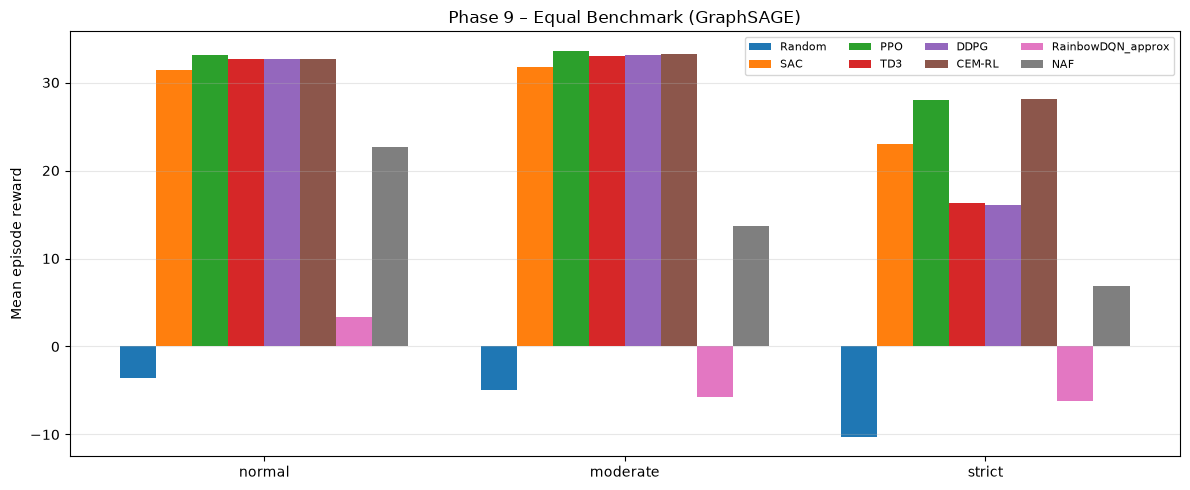


Cell 4 completed successfully.
PHASE 9 COMPLETED.


In [5]:
# Phase 9 – Cell 4: Final equal benchmark + winner by score only

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import SAC, PPO, TD3, DDPG

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
OUT_MODEL = PROJECT / "outputs" / "phase9" / "models"
OUT_TAB = PROJECT / "outputs" / "phase9" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase9" / "figures"
OUT_DATA = PROJECT / "outputs" / "phase9" / "data"

print("=" * 60)
print("Phase 9 – Cell 4: Final benchmark (GraphSAGE, equal)")
print("=" * 60)

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

def eval_sb3(cls, path, level, n_ep=15):
    model = cls.load(str(path))
    env = EconomicsNetworkEnv(base_features, emb, sr_vector, panel, nodes, level=level, seed=999)
    rewards, srs = [], []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=999 + ep)
        done, tot, info = False, 0.0, {}
        while not done:
            a, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(a)
            tot += r
            done = term or trunc
        rewards.append(tot); srs.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(srs)), float(np.nanstd(srs))

rows = []
levels = ["normal", "moderate", "strict"]
for level in levels:
    for name, cls in [("SAC", SAC), ("PPO", PPO), ("TD3", TD3), ("DDPG", DDPG)]:
        p = OUT_MODEL / f"{name}_{level}_gs.zip"
        if not p.exists():
            print(f"Missing {p.name}")
            continue
        mr, sr, ms, ss = eval_sb3(cls, p, level)
        rows.append({"algorithm": name, "level": level, "embedding": "GraphSAGE",
                     "mean_reward": mr, "std_reward": sr,
                     "mean_sr_improve": ms, "std_sr_improve": ss})
        print(f"{name:5s} | {level:8s} | R={mr:.3f} | dSR={ms:.3f}")

extra = pd.read_csv(OUT_TAB / "dqn_naf_cem_3levels_gs.csv")
rows.extend(extra.to_dict("records"))

rnd = pd.read_csv(PROJECT / "outputs" / "phase8" / "tables" / "random_baseline_3levels.csv")
for _, r in rnd.iterrows():
    rows.append({"algorithm": "Random", "level": r["level"], "embedding": "GraphSAGE",
                 "mean_reward": r["mean_reward"], "std_reward": r["std_reward"],
                 "mean_sr_improve": r["mean_sr_improve"], "std_sr_improve": r["std_sr_improve"]})

bench = pd.DataFrame(rows)
bench.to_csv(OUT_TAB / "phase9_full_benchmark_gs_equal.csv", index=False)
print("\n=== FULL BENCHMARK ===")
print(bench.sort_values(["level", "mean_reward"], ascending=[True, False]).to_string(index=False))

# Overall winner: best mean_reward across all algo×level (excluding Random)
comp = bench[bench["algorithm"] != "Random"].copy()
winner = comp.sort_values("mean_reward", ascending=False).iloc[0]
print("\n>>> WINNER (by mean_reward only):")
print(f"    algorithm = {winner['algorithm']}")
print(f"    level     = {winner['level']}")
print(f"    reward    = {winner['mean_reward']:.4f}")
print(f"    dSR       = {winner['mean_sr_improve']:.4f}")

pd.DataFrame([winner]).to_csv(OUT_TAB / "phase9_winner.csv", index=False)
(OUT_DATA / "phase9_winner.txt").write_text(
    f"{winner['algorithm']}|{winner['level']}|{winner['mean_reward']:.6f}"
)

# Per-level winners
print("\n--- Best per level ---")
for lv in levels:
    sub = comp[comp.level == lv].sort_values("mean_reward", ascending=False).iloc[0]
    print(f"  {lv:8s}: {sub['algorithm']:18s} R={sub['mean_reward']:.3f} dSR={sub['mean_sr_improve']:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
algs = ["Random", "SAC", "PPO", "TD3", "DDPG", "CEM-RL", "RainbowDQN_approx", "NAF"]
x = np.arange(len(levels))
width = 0.1
for i, alg in enumerate(algs):
    vals = []
    for lv in levels:
        sub = bench[(bench.algorithm == alg) & (bench.level == lv)]
        vals.append(float(sub["mean_reward"].iloc[0]) if len(sub) else np.nan)
    ax.bar(x + i * width, vals, width, label=alg)
ax.set_xticks(x + 3.5 * width)
ax.set_xticklabels(levels)
ax.set_ylabel("Mean episode reward")
ax.set_title("Phase 9 – Equal Benchmark (GraphSAGE)")
ax.legend(ncol=4, fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase9_benchmark_gs_equal.png", dpi=150)
plt.show()

print("\nCell 4 completed successfully.")
print("PHASE 9 COMPLETED.")